<a href="https://colab.research.google.com/github/sampadathapachhetri/Capstone-Project/blob/urvi/Capstonefinalfinal.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving cleaned_interaction_data.csv to cleaned_interaction_data.csv


In [ ]:
# INSTALL & IMPORTS
!pip install Levenshtein imbalanced-learn lightgbm xgboost scikit-learn joblib --quiet
print("All dependencies installed successfully!")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 153.3/153.3 kB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 42.8 MB/s eta 0:00:00
All dependencies installed successfully!


In [ ]:
#Import's
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import Levenshtein
import joblib
import time
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate, RandomizedSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, roc_auc_score,
    roc_curve
)
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
import lightgbm as lgb
from joblib import Parallel, delayed
import datetime

plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'DejaVu Sans'
sns.set_theme(style='whitegrid', palette='muted')

print("All libraries imported successfully!")

All libraries imported successfully!


In [ ]:
# DATA LOADING
DATA_PATH = list(uploaded.keys())[0]
print(f"Loading data from: {DATA_PATH}")

df = pd.read_csv(DATA_PATH)

print(f"\nDataset Overview:")
print(f"  Shape        : {df.shape[0]:,} rows x {df.shape[1]} columns")
print(f"  Columns      : {df.columns.tolist()}")
print(f"  Memory Usage : {df.memory_usage(deep=True).sum() / 1024**2:.1f} MB")

df.head()


Loading data from: cleaned_interaction_data.csv

Dataset Overview:
  Shape        : 2,910,552 rows x 5 columns
  Columns      : ['drug1_id', 'drug2_id', 'description', 'severity', 'severity_label']
  Memory Usage : 899.4 MB


,drug1_id,drug2_id,description,severity,severity_label
0,DB00001,DB06605,Apixaban may increase the anticoagulant activi...,moderate,1
1,DB00001,DB06695,Dabigatran etexilate may increase the anticoag...,moderate,1
2,DB00001,DB01254,The risk or severity of bleeding and hemorrhag...,high,2
3,DB00001,DB01609,The risk or severity of gastrointestinal bleed...,moderate,1
4,DB00001,DB01586,The risk or severity of bleeding and bruising ...,moderate,1


In [ ]:
# BASIC EXPLORATION
print("Data Types:")
print(df.dtypes)
print("\nMissing Values:")
print(df.isnull().sum())
print("\nOriginal Severity Distribution:")
print(df['severity'].value_counts())
print("\nSeverity Label Distribution:")
print(df['severity_label'].value_counts())


Data Types:
drug1_id          object
drug2_id          object
description       object
severity          object
severity_label     int64
dtype: object

Missing Values:
drug1_id          0
drug2_id          0
description       0
severity          0
severity_label    0
dtype: int64

Original Severity Distribution:
severity
moderate    2816046
high          91318
low            3188
Name: count, dtype: int64

Severity Label Distribution:
severity_label
1    2816046
2      91318
0       3188
Name: count, dtype: int64


In [ ]:
# CLASS ENGINEERING
METABOLISM_KEYWORDS = [
    'metabolism', 'enzyme', 'CYP', 'cytochrome',
    'excretion', 'clearance', 'serum concentration'
]

def assign_new_class(row):
    severity = row['severity'].strip().lower()
    if severity == 'low':
        return 'Low'
    elif severity == 'high':
        return 'High'
    elif severity == 'moderate':
        desc = str(row['description']).lower()
        for kw in METABOLISM_KEYWORDS:
            if kw.lower() in desc:
                return 'Moderate-Metabolism'
        return 'Moderate-Other'
    else:
        return 'Unknown'

print("Applying class engineering")
df['severity_new'] = df.apply(assign_new_class, axis=1)

print("\nNew Class Distribution:")
print(df['severity_new'].value_counts())
print(f"\nUnknown assignments: {(df['severity_new'] == 'Unknown').sum()}")


Applying class engineering

New Class Distribution:
severity_new
Moderate-Other         1752878
Moderate-Metabolism    1063168
High                     91318
Low                       3188
Name: count, dtype: int64

Unknown assignments: 0


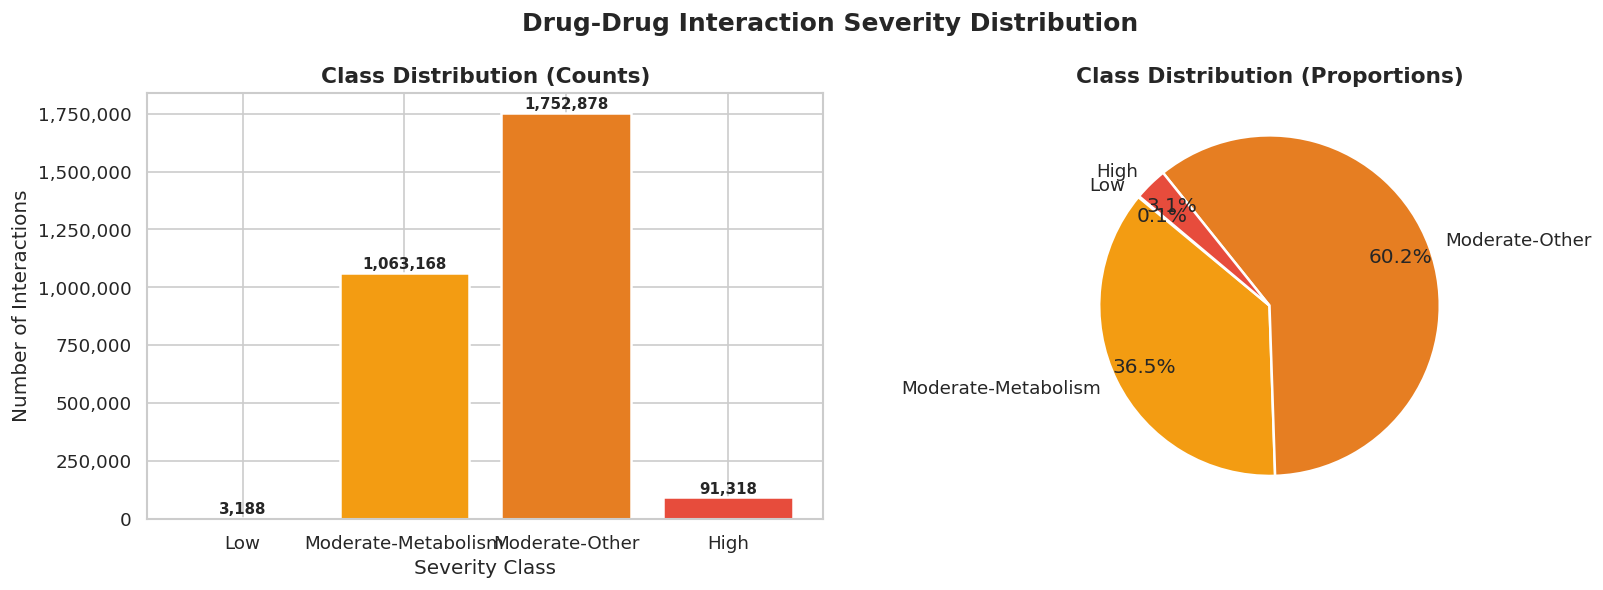

In [ ]:

# EDA OF CLASS DISTRIBUTION
class_order = ['Low', 'Moderate-Metabolism', 'Moderate-Other', 'High']
colors = ['#2ecc71', '#f39c12', '#e67e22', '#e74c3c']
counts = [df['severity_new'].value_counts().get(c, 0) for c in class_order]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

bars = axes[0].bar(class_order, counts, color=colors, edgecolor='white', linewidth=1.5)
axes[0].set_title('Class Distribution (Counts)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Severity Class')
axes[0].set_ylabel('Number of Interactions')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
for bar, cnt in zip(bars, counts):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5000,
                 f'{cnt:,}', ha='center', va='bottom', fontsize=9, fontweight='bold')

axes[1].pie(counts, labels=class_order, colors=colors, autopct='%1.1f%%',
            startangle=140, pctdistance=0.82,
            wedgeprops=dict(edgecolor='white', linewidth=1.5))
axes[1].set_title('Class Distribution (Proportions)', fontsize=13, fontweight='bold')

plt.suptitle('Drug-Drug Interaction Severity Distribution', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('eda_class_distribution.png', bbox_inches='tight', dpi=150)
plt.show()


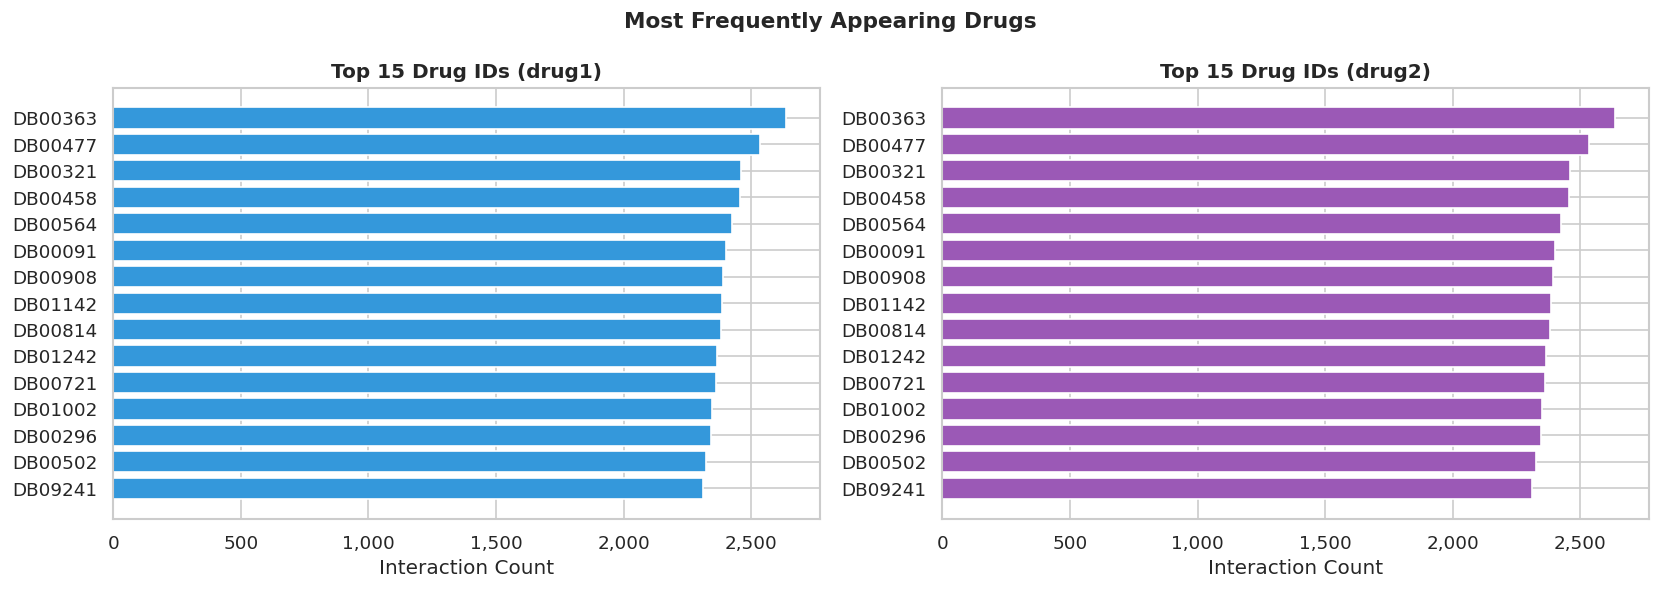

In [ ]:

# EDA OF TOP DRUG IDS
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

top_drug1 = df['drug1_id'].value_counts().head(15)
top_drug2 = df['drug2_id'].value_counts().head(15)

axes[0].barh(top_drug1.index[::-1], top_drug1.values[::-1], color='#3498db', edgecolor='white')
axes[0].set_title('Top 15 Drug IDs (drug1)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Interaction Count')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

axes[1].barh(top_drug2.index[::-1], top_drug2.values[::-1], color='#9b59b6', edgecolor='white')
axes[1].set_title('Top 15 Drug IDs (drug2)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Interaction Count')
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

plt.suptitle('Most Frequently Appearing Drugs', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('eda_top_drugs.png', bbox_inches='tight', dpi=150)
plt.show()

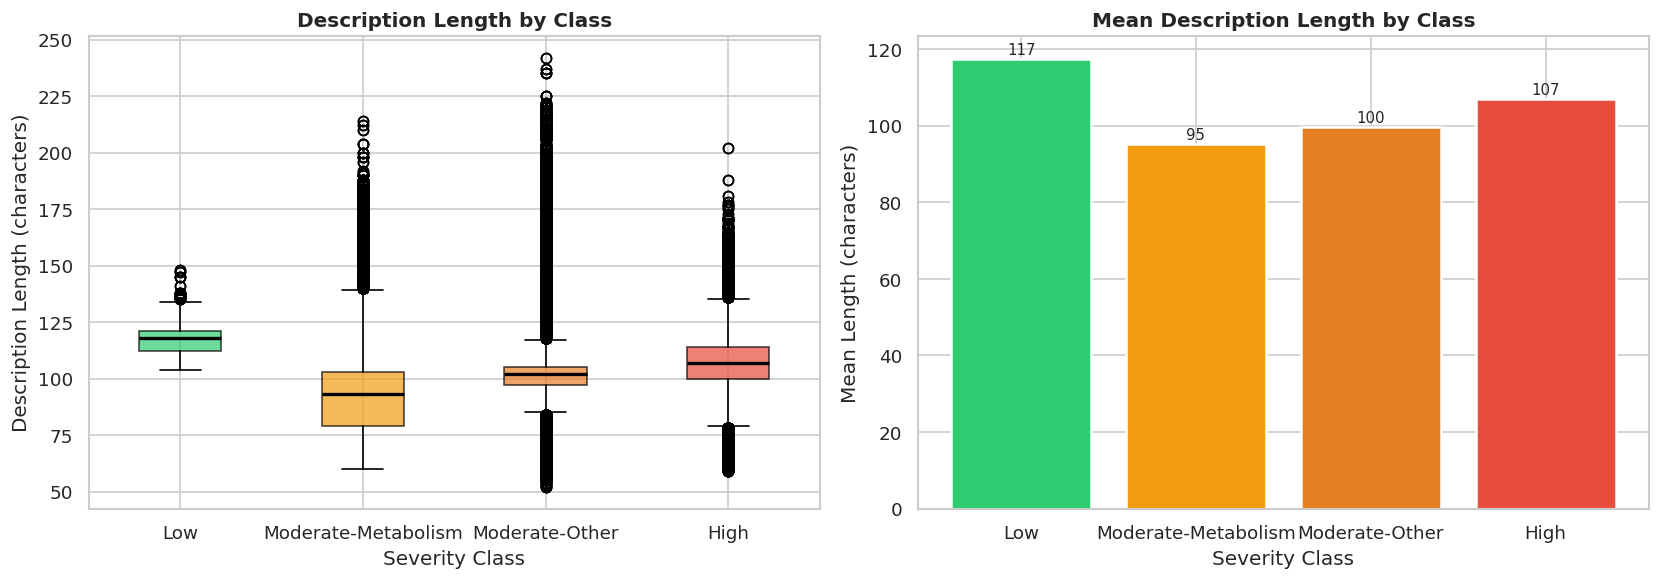

In [ ]:

# EDA OF DESCRIPTION LENGTH
df['desc_length'] = df['description'].astype(str).apply(len)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

bp_data = [df[df['severity_new'] == c]['desc_length'].values for c in class_order]
bp = axes[0].boxplot(bp_data, labels=class_order, patch_artist=True,
                     medianprops=dict(color='black', linewidth=2))
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
axes[0].set_title('Description Length by Class', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Severity Class')
axes[0].set_ylabel('Description Length (characters)')

mean_lens = [df[df['severity_new'] == c]['desc_length'].mean() for c in class_order]
bars = axes[1].bar(class_order, mean_lens, color=colors, edgecolor='white', linewidth=1.5)
axes[1].set_title('Mean Description Length by Class', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Severity Class')
axes[1].set_ylabel('Mean Length (characters)')
for bar, v in zip(bars, mean_lens):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                 f'{v:.0f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('eda_description_length.png', bbox_inches='tight', dpi=150)
plt.show()

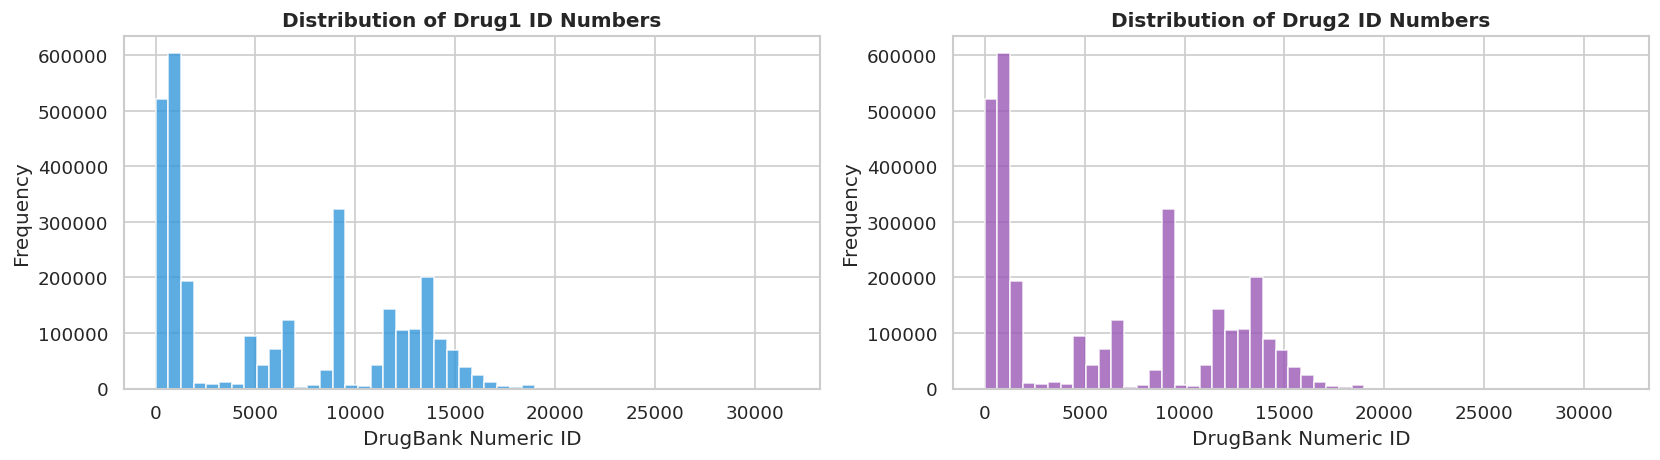

Drug1 ID range: DB00001 -> DB31654
Drug2 ID range: DB00001 -> DB31654
Total unique drugs: 4,629


In [ ]:

# EDA OF DRUG ID NUMBER DISTRIBUTION
df['drug1_num'] = df['drug1_id'].str.extract(r'DB(\d+)').astype(float)
df['drug2_num'] = df['drug2_id'].str.extract(r'DB(\d+)').astype(float)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].hist(df['drug1_num'].dropna(), bins=50, color='#3498db', edgecolor='white', alpha=0.8)
axes[0].set_title('Distribution of Drug1 ID Numbers', fontsize=12, fontweight='bold')
axes[0].set_xlabel('DrugBank Numeric ID')
axes[0].set_ylabel('Frequency')

axes[1].hist(df['drug2_num'].dropna(), bins=50, color='#9b59b6', edgecolor='white', alpha=0.8)
axes[1].set_title('Distribution of Drug2 ID Numbers', fontsize=12, fontweight='bold')
axes[1].set_xlabel('DrugBank Numeric ID')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.savefig('eda_drug_id_distribution.png', bbox_inches='tight', dpi=150)
plt.show()

print(f"Drug1 ID range: DB{int(df['drug1_num'].min()):05d} -> DB{int(df['drug1_num'].max()):05d}")
print(f"Drug2 ID range: DB{int(df['drug2_num'].min()):05d} -> DB{int(df['drug2_num'].max()):05d}")
print(f"Total unique drugs: {pd.concat([df['drug1_id'], df['drug2_id']]).nunique():,}")


In [ ]:
# LABEL ENCODING
all_drugs = pd.concat([df['drug1_id'], df['drug2_id']]).unique()
le_combined = LabelEncoder().fit(all_drugs)

df['drug1_encoded'] = le_combined.transform(df['drug1_id'])
df['drug2_encoded'] = le_combined.transform(df['drug2_id'])

print(f"Drug ID encoding complete.")
print(f"  Total unique drug IDs : {len(le_combined.classes_):,}")
print(f"  Encoding range        : 0 -> {len(le_combined.classes_) - 1}")
print(f"  Example: DB00001 -> {le_combined.transform(['DB00001'])[0]}")


Drug ID encoding complete.
  Total unique drug IDs : 4,629
  Encoding range        : 0 -> 4628
  Example: DB00001 -> 0


In [ ]:

# LEVENSHTEIN SIMILARITY
def levenshtein_similarity(s1, s2):
    dist = Levenshtein.distance(str(s1), str(s2))
    max_len = max(len(str(s1)), len(str(s2)), 1)
    return 1.0 - (dist / max_len)

print("Computing Levenshtein similarity (parallelised)")
t0 = time.time()
lev_scores = Parallel(n_jobs=-1)(
    delayed(levenshtein_similarity)(d1, d2)
    for d1, d2 in zip(df['drug1_id'], df['drug2_id'])
)
df['lev_similarity'] = lev_scores
print(f"Done in {time.time() - t0:.1f} seconds")
print(df['lev_similarity'].describe().round(4))

Computing Levenshtein similarity (parallelised)
Done in 26.7 seconds
count    2.910552e+06
mean     4.483000e-01
std      1.243000e-01
min      2.857000e-01
25%      4.286000e-01
50%      4.286000e-01
75%      5.714000e-01
max      8.571000e-01
Name: lev_similarity, dtype: float64


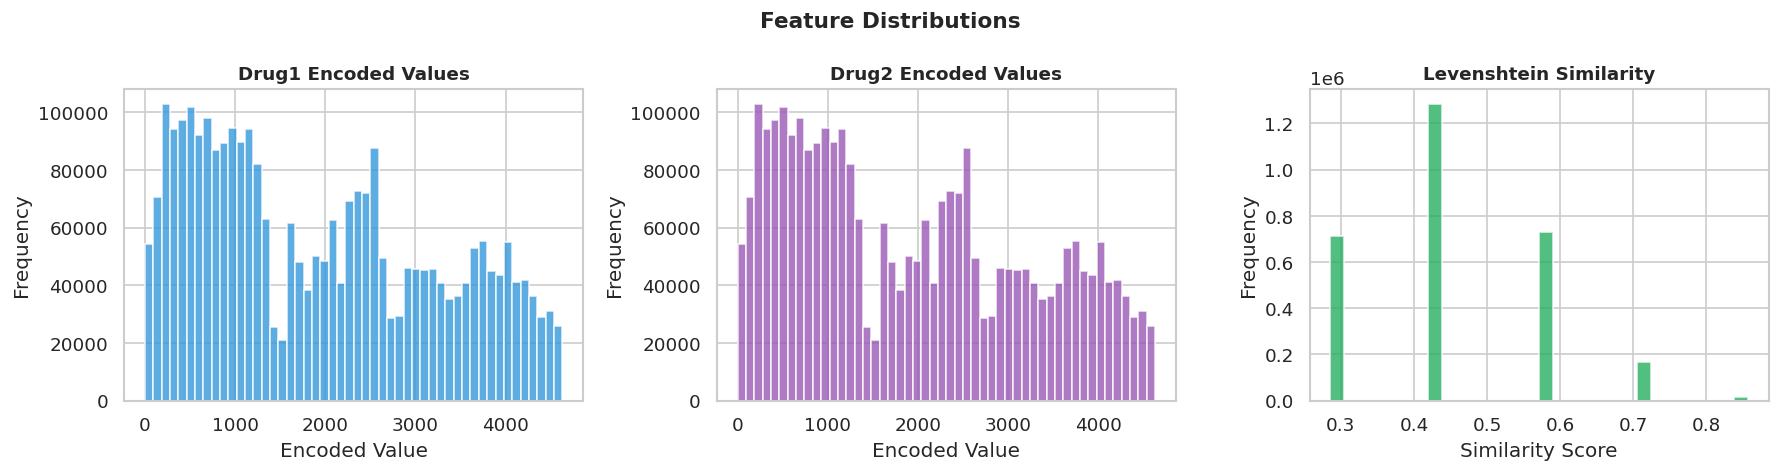

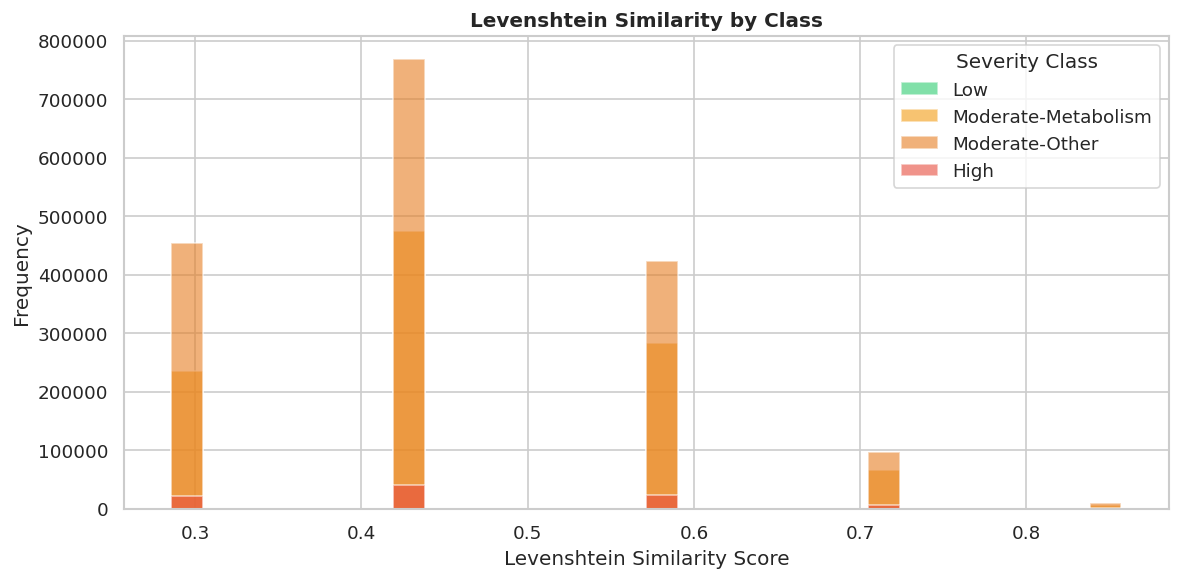

In [ ]:

# FEATURE DISTRIBUTION PLOTS
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(df['drug1_encoded'], bins=50, color='#3498db', edgecolor='white', alpha=0.8)
axes[0].set_title('Drug1 Encoded Values', fontsize=11, fontweight='bold')
axes[0].set_xlabel('Encoded Value')
axes[0].set_ylabel('Frequency')

axes[1].hist(df['drug2_encoded'], bins=50, color='#9b59b6', edgecolor='white', alpha=0.8)
axes[1].set_title('Drug2 Encoded Values', fontsize=11, fontweight='bold')
axes[1].set_xlabel('Encoded Value')
axes[1].set_ylabel('Frequency')

axes[2].hist(df['lev_similarity'], bins=30, color='#27ae60', edgecolor='white', alpha=0.8)
axes[2].set_title('Levenshtein Similarity', fontsize=11, fontweight='bold')
axes[2].set_xlabel('Similarity Score')
axes[2].set_ylabel('Frequency')

plt.suptitle('Feature Distributions', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('feature_distributions.png', bbox_inches='tight', dpi=150)
plt.show()

fig, ax = plt.subplots(figsize=(10, 5))
for cls, color in zip(class_order, colors):
    subset = df[df['severity_new'] == cls]['lev_similarity']
    ax.hist(subset, bins=30, alpha=0.6, label=cls, color=color, edgecolor='white')
ax.set_title('Levenshtein Similarity by Class', fontsize=12, fontweight='bold')
ax.set_xlabel('Levenshtein Similarity Score')
ax.set_ylabel('Frequency')
ax.legend(title='Severity Class')
plt.tight_layout()
plt.savefig('lev_similarity_by_class.png', bbox_inches='tight', dpi=150)
plt.show()


In [ ]:
# ADDITIONAL FEATURE ENGINEERING


print("  ADDITIONAL FEATURE ENGINEERING")


df['drug_id_diff']    = (df['drug1_num'] - df['drug2_num']).abs()
df['drug_id_sum']     = df['drug1_num'] + df['drug2_num']
df['drug_id_ratio']   = df[['drug1_num', 'drug2_num']].min(axis=1) / \
                         df[['drug1_num', 'drug2_num']].max(axis=1).replace(0, 1)

df['desc_word_count'] = df['description'].astype(str).apply(lambda x: len(x.split()))
df['desc_has_cyp']    = df['description'].str.contains('CYP|cytochrome', case=False).astype(int)
df['desc_has_excret'] = df['description'].str.contains('excretion|clearance', case=False).astype(int)
df['desc_has_serum']  = df['description'].str.contains('serum|concentration', case=False).astype(int)

print("  New features added: drug_id_diff, drug_id_sum, drug_id_ratio,")
print("  desc_word_count, desc_has_cyp, desc_has_excret, desc_has_serum")

FEATURES = ['drug1_encoded', 'drug2_encoded', 'lev_similarity']

FEATURES_EXT = [
    'drug1_encoded', 'drug2_encoded', 'lev_similarity',
    'drug_id_diff', 'drug_id_sum', 'drug_id_ratio',
    'desc_word_count', 'desc_has_cyp', 'desc_has_excret', 'desc_has_serum'
]

TARGET = 'severity_new'

X_ext = df[FEATURES_EXT].copy()
y_ext = df[TARGET].copy()

le_target = LabelEncoder()
y_ext_encoded = le_target.fit_transform(y_ext)

X_train_ext, X_test_ext, y_train_ext, y_test_ext = train_test_split(
    X_ext, y_ext_encoded,
    test_size=0.2, random_state=42, stratify=y_ext_encoded
)

print(f"\n  Extended feature matrix : {X_ext.shape}")
print(f"  Train : {X_train_ext.shape[0]:,}  |  Test : {X_test_ext.shape[0]:,}")
print(f"\n  Class label mapping:")
for i, cls in enumerate(le_target.classes_):
    print(f"    {i} -> {cls}")


  ADDITIONAL FEATURE ENGINEERING
  New features added: drug_id_diff, drug_id_sum, drug_id_ratio,
  desc_word_count, desc_has_cyp, desc_has_excret, desc_has_serum

  Extended feature matrix : (2910552, 10)
  Train : 2,328,441  |  Test : 582,111

  Class label mapping:
    0 -> High
    1 -> Low
    2 -> Moderate-Metabolism
    3 -> Moderate-Other


 OPTIMISED SMOTE
  After optimised SMOTE — shape : (4767825, 10)
  Class distribution:
Moderate-Other         1402302
Moderate-Metabolism    1121841
High                   1121841
Low                    1121841
Name: count, dtype: int64


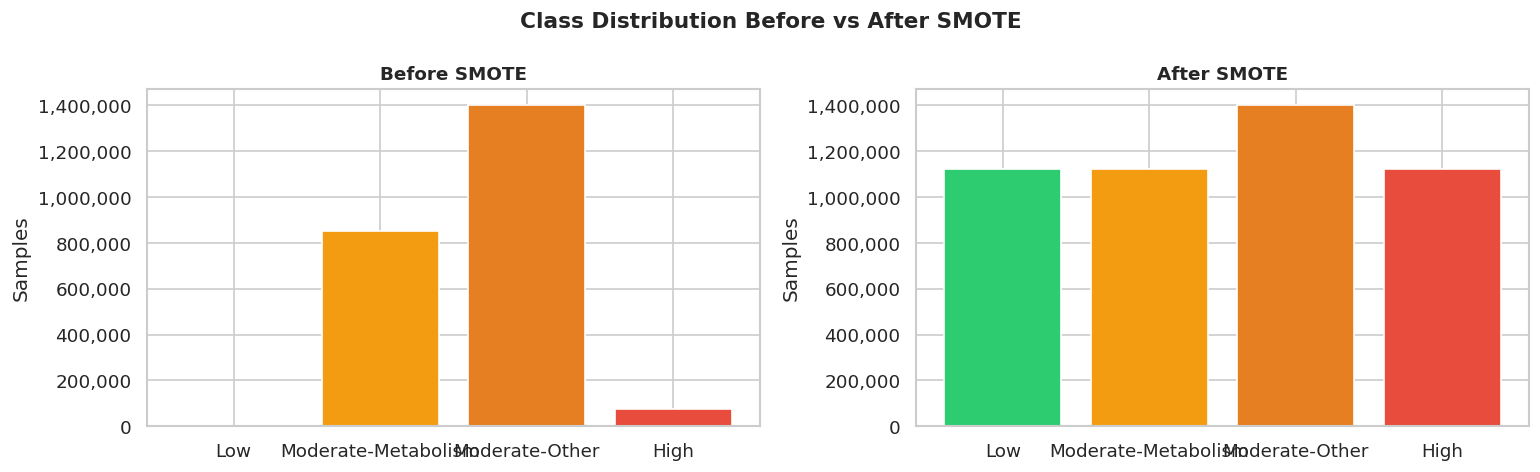

In [ ]:

# OPTIMISED SMOTE

print(" OPTIMISED SMOTE")

majority_count = pd.Series(y_train_ext).value_counts().max()
cap = int(majority_count * 0.8)
class_counts = pd.Series(y_train_ext).value_counts().to_dict()

sampling_strategy = {}
for cls, count in class_counts.items():
    if count < cap:

        sampling_strategy[cls] = cap
    else:

        sampling_strategy[cls] = count

smote_opt = SMOTE(
    k_neighbors=5,
    sampling_strategy=sampling_strategy,
    random_state=42
)
X_train_sm_ext, y_train_sm_ext = smote_opt.fit_resample(X_train_ext, y_train_ext)

after_dist_ext = (pd.Series(y_train_sm_ext)
                    .map(dict(enumerate(le_target.classes_)))
                    .value_counts())
print(f"  After optimised SMOTE — shape : {X_train_sm_ext.shape}")
print(f"  Class distribution:\n{after_dist_ext}")

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
before_counts = pd.Series(y_train_ext).map(dict(enumerate(le_target.classes_))).value_counts()
before_counts = before_counts.reindex(class_order).fillna(0)
after_counts  = after_dist_ext.reindex(class_order).fillna(0)

axes[0].bar(before_counts.index, before_counts.values, color=colors, edgecolor='white')
axes[0].set_title('Before SMOTE', fontsize=11, fontweight='bold')
axes[0].set_ylabel('Samples')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

axes[1].bar(after_counts.index, after_counts.values, color=colors, edgecolor='white')
axes[1].set_title('After SMOTE', fontsize=11, fontweight='bold')
axes[1].set_ylabel('Samples')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

plt.suptitle('Class Distribution Before vs After SMOTE', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('smote_comparison.png', bbox_inches='tight', dpi=150)
plt.show()

In [ ]:

# MODEL TRAINING


print(" MODEL TRAINING ")


X_tr, X_val, y_tr, y_val = train_test_split(
    X_train_sm_ext, y_train_sm_ext,
    test_size=0.1, random_state=42,
    stratify=y_train_sm_ext
)


 MODEL TRAINING 


In [ ]:
#  [1] Logistic Regression

print("\n  [1/4] Logistic Regression")
t0 = time.time()
lr_tuned = LogisticRegression(
    C=1.0,
    max_iter=300,
    class_weight='balanced',
    solver='saga',
    n_jobs=-1,
    random_state=42
)
lr_tuned.fit(X_train_sm_ext, y_train_sm_ext)
lr_train_time = time.time() - t0
print(f"     Done in {lr_train_time:.1f}s")

# [2] Random Forest

print("\n  [2/4] Random Forest")
t0 = time.time()
best_rf = RandomForestClassifier(
    n_estimators=150,
    max_depth=15,
    min_samples_split=5,
    min_samples_leaf=2,
    max_features='sqrt',
    class_weight='balanced',
    n_jobs=-1,
    random_state=42
)
best_rf.fit(X_train_sm_ext, y_train_sm_ext)
rf_tune_time = time.time() - t0
print(f"     Done in {rf_tune_time:.1f}s")

# [3] XGBoost

print("\n  [3/4] XGBoost ")
t0 = time.time()
best_xgb = XGBClassifier(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    tree_method='hist',
    use_label_encoder=False,
    eval_metric='mlogloss',
    early_stopping_rounds=20,
    random_state=42,
    n_jobs=-1,
    verbosity=0
)
best_xgb.fit(
    X_tr, y_tr,
    eval_set=[(X_val, y_val)],
    verbose=False
)
xgb_tune_time = time.time() - t0
print(f"     Stopped at tree : {best_xgb.best_iteration}")
print(f"     Done in          : {xgb_tune_time:.1f}s")

#  [4] LightGBM

print("\n  [4/4] LightGBM ")
t0 = time.time()
best_lgbm = LGBMClassifier(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.1,
    num_leaves=31,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_samples=20,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1,
    verbose=-1
)
best_lgbm.fit(
    X_tr, y_tr,
    eval_set=[(X_val, y_val)],
    callbacks=[
        lgb.early_stopping(20, verbose=False),
        lgb.log_evaluation(period=-1)
    ]
)
lgbm_tune_time = time.time() - t0
print(f"     Stopped at tree : {best_lgbm.best_iteration_}")
print(f"     Done in          : {lgbm_tune_time:.1f}s")

print("\n  All models trained!")


  [1/4] Logistic Regression
     Done in 1530.0s

  [2/4] Random Forest
     Done in 2030.0s

  [3/4] XGBoost 
     Stopped at tree : 499
     Done in          : 933.3s

  [4/4] LightGBM 
     Stopped at tree : 500
     Done in          : 740.1s

  All models trained!


In [ ]:

# COMPREHENSIVE BENCHMARKING



print(" COMPREHENSIVE BENCHMARKING")


tuned_models = {
    'Logistic Regression': lr_tuned,
    'Random Forest':       best_rf,
    'XGBoost':             best_xgb,
    'LightGBM':            best_lgbm,
}

train_time_map = {
    'Logistic Regression': lr_train_time,
    'Random Forest':       rf_tune_time,
    'XGBoost':             xgb_tune_time,
    'LightGBM':            lgbm_tune_time,
}

benchmark_results = {}
results = {}

for name, model in tuned_models.items():
    print(f"\n  Benchmarking: {name}")

    t_pred_start = time.time()
    y_pred = model.predict(X_test_ext)
    pred_time = (time.time() - t_pred_start) * 1000
    y_prob = model.predict_proba(X_test_ext)

    acc  = accuracy_score(y_test_ext, y_pred)
    prec = precision_score(y_test_ext, y_pred, average='weighted', zero_division=0)
    rec  = recall_score(y_test_ext, y_pred, average='weighted', zero_division=0)
    f1   = f1_score(y_test_ext, y_pred, average='weighted', zero_division=0)

    try:
        auc = roc_auc_score(y_test_ext, y_prob, multi_class='ovr', average='macro')
    except Exception:
        auc = float('nan')

    benchmark_results[name] = {
        'Accuracy':        round(acc,   4),
        'Precision (W)':   round(prec,  4),
        'Recall (W)':      round(rec,   4),
        'F1 (Weighted)':   round(f1,    4),
        'ROC-AUC (Macro)': round(auc,   4),
        'CV Mean F1':      0.0,
        'CV Std F1':       0.0,
        'Train Time (s)':  round(train_time_map[name], 1),
        'Pred Time (ms)':  round(pred_time, 2),
    }
    results[name] = {
        'Accuracy':       round(acc,  4),
        'Precision':      round(prec, 4),
        'Recall':         round(rec,  4),
        'F1 (Weighted)':  round(f1,   4),
        'Train Time (s)': round(train_time_map[name], 1),
    }
    print(f"    Acc={acc:.4f}  F1={f1:.4f}  AUC={auc:.4f}  Time={pred_time:.1f}ms")


 COMPREHENSIVE BENCHMARKING

  Benchmarking: Logistic Regression
    Acc=0.1489  F1=0.2289  AUC=0.6466  Time=215.7ms

  Benchmarking: Random Forest
    Acc=0.8889  F1=0.9146  AUC=0.9704  Time=9435.9ms

  Benchmarking: XGBoost
    Acc=0.9286  F1=0.9417  AUC=0.9809  Time=29386.1ms

  Benchmarking: LightGBM
    Acc=0.9154  F1=0.9330  AUC=0.9813  Time=88456.5ms


In [ ]:

# RANKED PERFORMANCE TABLE


print(" RANKED PERFORMANCE TABLE")


bench_df = (pd.DataFrame(benchmark_results).T
              .sort_values('F1 (Weighted)', ascending=False))

print("\n  Full Benchmark — sorted by Weighted F1:")
print(bench_df.to_string())

best_model_name_tuned = bench_df.index[0]
best_f1_tuned  = bench_df.loc[best_model_name_tuned, 'F1 (Weighted)']
best_model_obj = tuned_models[best_model_name_tuned]

print(f"\n  Best Model  : {best_model_name_tuned}")
print(f"  Weighted F1 : {best_f1_tuned:.4f}")
print(f"  Accuracy    : {benchmark_results[best_model_name_tuned]['Accuracy']:.4f}")


 RANKED PERFORMANCE TABLE

  Full Benchmark — sorted by Weighted F1:
                     Accuracy  Precision (W)  Recall (W)  F1 (Weighted)  ROC-AUC (Macro)  CV Mean F1  CV Std F1  Train Time (s)  Pred Time (ms)
XGBoost                0.9286         0.9615      0.9286         0.9417           0.9809         0.0        0.0           933.3        29386.13
LightGBM               0.9154         0.9613      0.9154         0.9330           0.9813         0.0        0.0           740.1        88456.52
Random Forest          0.8889         0.9537      0.8889         0.9146           0.9704         0.0        0.0          2030.0         9435.90
Logistic Regression    0.1489         0.7064      0.1489         0.2289           0.6466         0.0        0.0          1530.0          215.68

  Best Model  : XGBoost
  Weighted F1 : 0.9417
  Accuracy    : 0.9286


In [ ]:

# BENCHMARK VISUALISATIONS

print(" BENCHMARK VISUALISATIONS")


model_labels  = list(bench_df.index)
palette_bench = ['#3498db', '#e74c3c', '#2ecc71', '#f39c12']







 BENCHMARK VISUALISATIONS


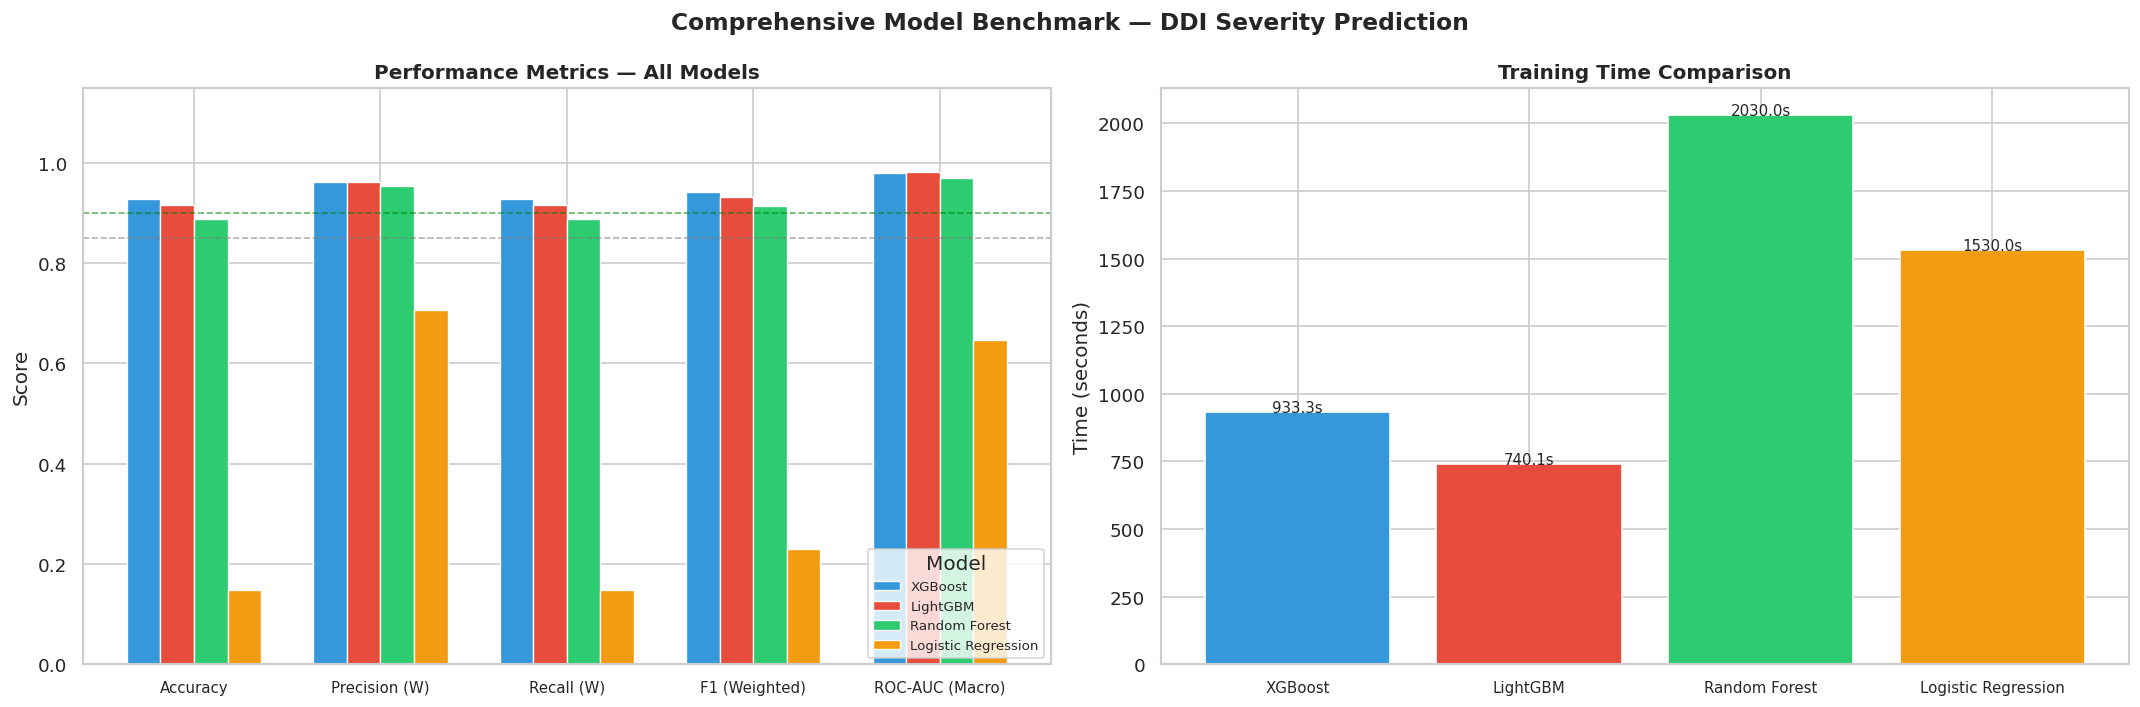

In [ ]:
# Fig 1: Metric comparison bar chart
perf_metrics = ['Accuracy', 'Precision (W)', 'Recall (W)', 'F1 (Weighted)', 'ROC-AUC (Macro)']
x = np.arange(len(perf_metrics))
width = 0.18

fig, axes = plt.subplots(1, 2, figsize=(18, 6))
for i, (mname, color) in enumerate(zip(model_labels, palette_bench)):
    vals = [benchmark_results[mname][m] for m in perf_metrics]
    axes[0].bar(x + i * width, vals, width, label=mname, color=color,
                edgecolor='white', linewidth=0.8)

axes[0].set_xticks(x + width * 1.5)
axes[0].set_xticklabels(perf_metrics, fontsize=9)
axes[0].set_ylim(0, 1.15)
axes[0].set_title('Performance Metrics — All Models', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Score')
axes[0].legend(title='Model', fontsize=8, loc='lower right')
axes[0].axhline(0.85, color='gray', lw=1, ls='--', alpha=0.6)
axes[0].axhline(0.90, color='green', lw=1, ls='--', alpha=0.6)

train_times = [benchmark_results[m]['Train Time (s)'] for m in model_labels]
bars = axes[1].bar(range(len(model_labels)), train_times, color=palette_bench, edgecolor='white')
axes[1].set_xticks(range(len(model_labels)))
axes[1].set_xticklabels(model_labels, fontsize=9)
axes[1].set_title('Training Time Comparison', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Time (seconds)')
for bar, t in zip(bars, train_times):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                 f'{t:.1f}s', ha='center', fontsize=9)

plt.suptitle('Comprehensive Model Benchmark — DDI Severity Prediction',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('benchmark_performance.png', bbox_inches='tight', dpi=150)
plt.show()

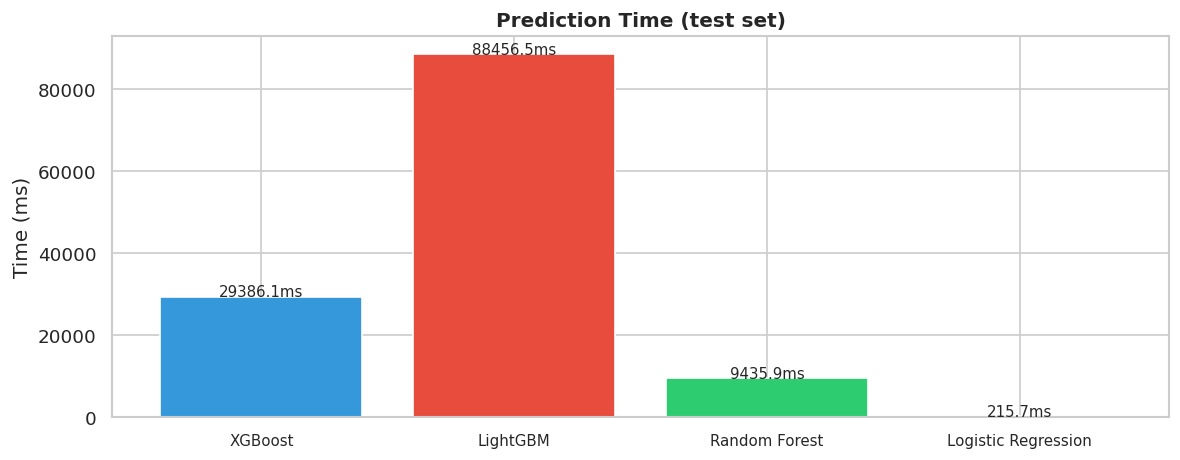

In [ ]:
# Fig 2: Prediction time
fig, ax = plt.subplots(figsize=(10, 4))
pred_times = [benchmark_results[m]['Pred Time (ms)'] for m in model_labels]
bars2 = ax.bar(range(len(model_labels)), pred_times, color=palette_bench, edgecolor='white')
ax.set_xticks(range(len(model_labels)))
ax.set_xticklabels(model_labels, fontsize=9)
ax.set_title('Prediction Time (test set)', fontsize=12, fontweight='bold')
ax.set_ylabel('Time (ms)')
for bar, t in zip(bars2, pred_times):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
            f'{t:.1f}ms', ha='center', fontsize=9)
plt.tight_layout()
plt.savefig('benchmark_efficiency.png', bbox_inches='tight', dpi=150)
plt.show()

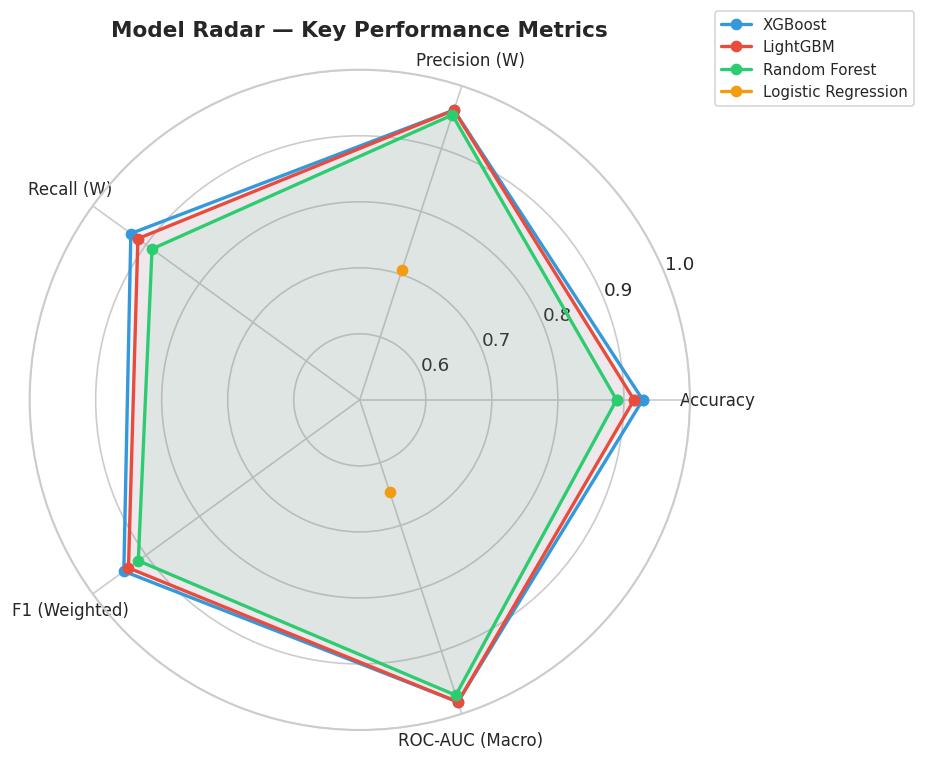

In [ ]:
# Fig 3: Radar chart
radar_metrics = ['Accuracy', 'Precision (W)', 'Recall (W)', 'F1 (Weighted)', 'ROC-AUC (Macro)']
N = len(radar_metrics)
angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angles += angles[:1]

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
for mname, color in zip(model_labels, palette_bench):
    vals = [benchmark_results[mname][m] for m in radar_metrics]
    vals += vals[:1]
    ax.plot(angles, vals, 'o-', lw=2, label=mname, color=color)
    ax.fill(angles, vals, alpha=0.08, color=color)

ax.set_thetagrids(np.degrees(angles[:-1]), radar_metrics, fontsize=10)
ax.set_ylim(0.5, 1.0)
ax.set_title('Model Radar — Key Performance Metrics',
             fontsize=13, fontweight='bold', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.1), fontsize=9)
plt.tight_layout()
plt.savefig('benchmark_radar.png', bbox_inches='tight', dpi=150)
plt.show()

In [ ]:


# BEST MODEL DETAILED EVALUATION

print(f" BEST MODEL DETAILED EVALUATION: {best_model_name_tuned}")


target_names = le_target.classes_
y_pred_best  = best_model_obj.predict(X_test_ext)
y_prob_best  = best_model_obj.predict_proba(X_test_ext)

print(f"\n  Classification Report — {best_model_name_tuned}")

print(classification_report(y_test_ext, y_pred_best,
                             target_names=target_names, digits=4))







 BEST MODEL DETAILED EVALUATION: XGBoost

  Classification Report — XGBoost
                     precision    recall  f1-score   support

               High     0.3063    0.6535    0.4171     18264
                Low     0.0935    0.9513    0.1702       637
Moderate-Metabolism     0.9875    0.9979    0.9927    212634
     Moderate-Other     0.9815    0.9009    0.9395    350576

           accuracy                         0.9286    582111
          macro avg     0.5922    0.8759    0.6299    582111
       weighted avg     0.9615    0.9286    0.9417    582111



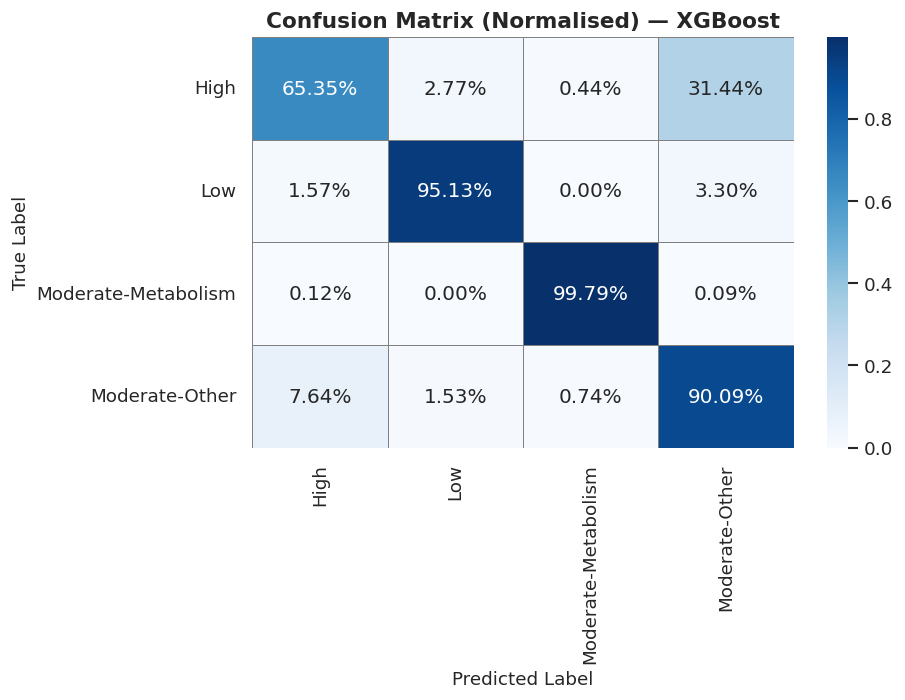


  Raw Confusion Matrix:
                      High   Low  Moderate-Metabolism  Moderate-Other
High                 11935   505                   81            5743
Low                     10   606                    0              21
Moderate-Metabolism    253     2               212192             187
Moderate-Other       26768  5369                 2602          315837


In [ ]:
# Confusion matrix
fig, ax = plt.subplots(figsize=(8, 6))
cm      = confusion_matrix(y_test_ext, y_pred_best)
cm_norm = cm.astype('float') / cm.sum(axis=1, keepdims=True)

sns.heatmap(cm_norm, annot=True, fmt='.2%', cmap='Blues',
            xticklabels=target_names, yticklabels=target_names,
            linewidths=0.5, linecolor='gray', ax=ax)
ax.set_title(f'Confusion Matrix (Normalised) — {best_model_name_tuned}',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Predicted Label', fontsize=11)
ax.set_ylabel('True Label', fontsize=11)
plt.tight_layout()
plt.savefig('confusion_matrix.png', bbox_inches='tight', dpi=150)
plt.show()

print("\n  Raw Confusion Matrix:")
print(pd.DataFrame(cm, index=target_names, columns=target_names))

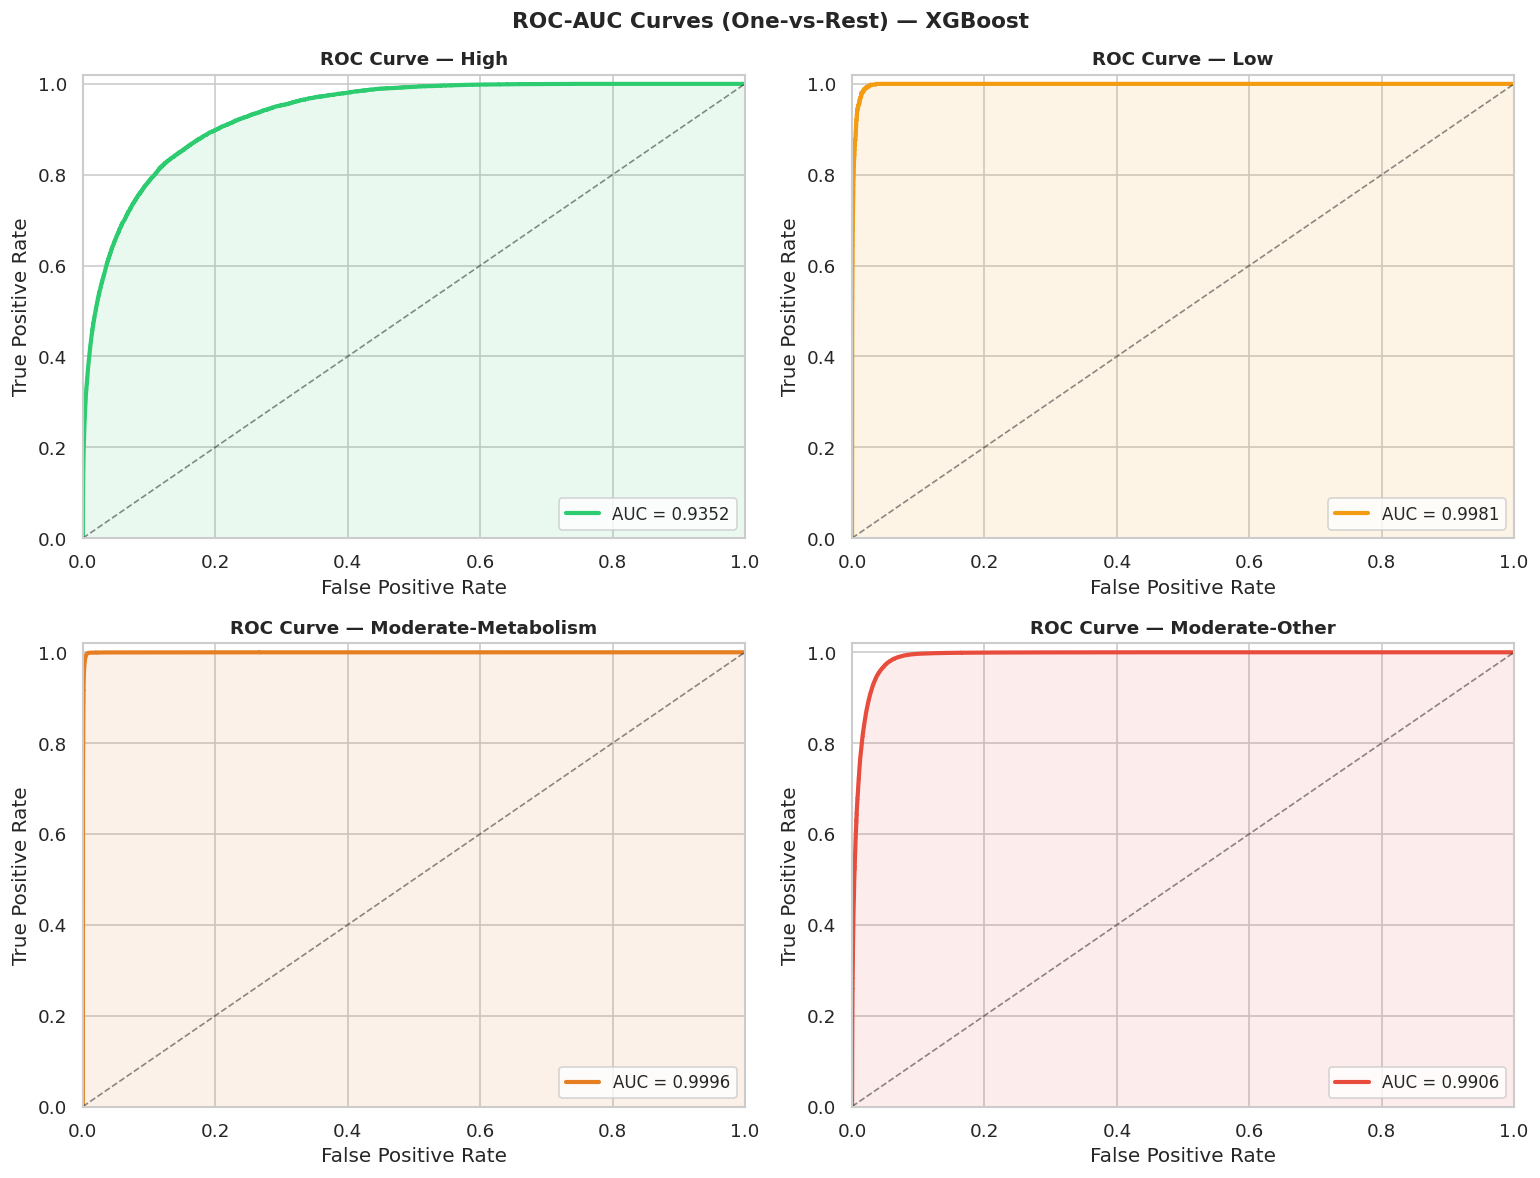


  AUC Scores by Class:
    High                     : 0.9352
    Low                      : 0.9981
    Moderate-Metabolism      : 0.9996
    Moderate-Other           : 0.9906

  Macro-Average AUC: 0.9809


In [ ]:
# ROC-AUC curves
fig, axes = plt.subplots(2, 2, figsize=(13, 10))
axes = axes.flatten()
class_colors = ['#2ecc71', '#f39c12', '#e67e22', '#e74c3c']
auc_scores = {}

for i, (cls, color) in enumerate(zip(target_names, class_colors)):
    y_bin = (y_test_ext == i).astype(int)
    fpr, tpr, _ = roc_curve(y_bin, y_prob_best[:, i])
    auc = roc_auc_score(y_bin, y_prob_best[:, i])
    auc_scores[cls] = auc

    axes[i].plot(fpr, tpr, color=color, lw=2.5, label=f'AUC = {auc:.4f}')
    axes[i].plot([0, 1], [0, 1], 'k--', lw=1, alpha=0.5)
    axes[i].fill_between(fpr, tpr, alpha=0.1, color=color)
    axes[i].set_title(f'ROC Curve — {cls}', fontsize=11, fontweight='bold')
    axes[i].set_xlabel('False Positive Rate')
    axes[i].set_ylabel('True Positive Rate')
    axes[i].legend(loc='lower right', fontsize=10)
    axes[i].set_xlim([0, 1])
    axes[i].set_ylim([0, 1.02])

plt.suptitle(f'ROC-AUC Curves (One-vs-Rest) — {best_model_name_tuned}',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('roc_auc_curves.png', bbox_inches='tight', dpi=150)
plt.show()

macro_auc = np.mean(list(auc_scores.values()))
print("\n  AUC Scores by Class:")
for cls, auc in auc_scores.items():
    print(f"    {cls:25s}: {auc:.4f}")
print(f"\n  Macro-Average AUC: {macro_auc:.4f}")

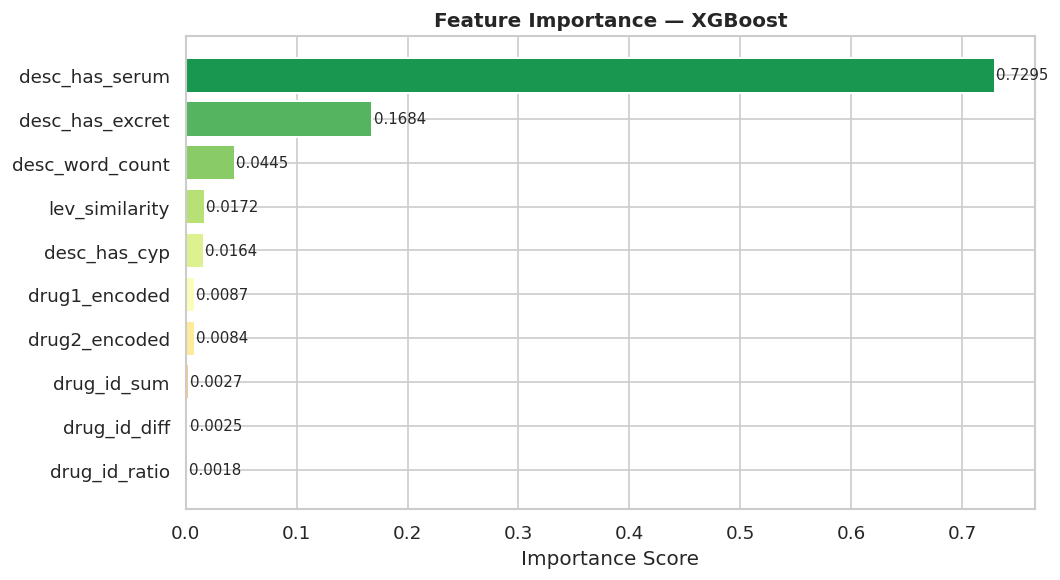

In [ ]:
# Feature importance
fig, ax = plt.subplots(figsize=(9, 5))

if hasattr(best_model_obj, 'feature_importances_'):
    importances = best_model_obj.feature_importances_
    sorted_idx  = np.argsort(importances)
    feat_colors = plt.cm.RdYlGn(np.linspace(0.2, 0.9, len(FEATURES_EXT)))
    ax.barh(
        [FEATURES_EXT[i] for i in sorted_idx],
        importances[sorted_idx],
        color=feat_colors, edgecolor='white', linewidth=1.2
    )
    ax.set_title(f'Feature Importance — {best_model_name_tuned}',
                 fontsize=12, fontweight='bold')
    ax.set_xlabel('Importance Score')
    for i, (idx, v) in enumerate(zip(sorted_idx, importances[sorted_idx])):
        ax.text(v + 0.001, i, f'{v:.4f}', va='center', fontsize=9)
elif hasattr(best_model_obj, 'coef_'):
    coef_mean  = np.mean(np.abs(best_model_obj.coef_), axis=0)
    sorted_idx = np.argsort(coef_mean)
    ax.barh(
        [FEATURES_EXT[i] for i in sorted_idx],
        coef_mean[sorted_idx],
        color='#3498db', edgecolor='white'
    )
    ax.set_title(f'Feature Importance (Mean |Coef|) — {best_model_name_tuned}',
                 fontsize=12, fontweight='bold')
    ax.set_xlabel('Mean |Coefficient|')

plt.tight_layout()
plt.savefig('feature_importance.png', bbox_inches='tight', dpi=150)
plt.show()


  Running 5-Fold CV for best model only: XGBoost

  5-Fold CV Results — XGBoost:
  accuracy                    : 0.9141 +/- 0.0008
    folds: ['0.9134', '0.9146', '0.9148', '0.9148', '0.9128']
  f1_weighted                 : 0.9315 +/- 0.0005
    folds: ['0.9311', '0.9318', '0.9321', '0.9320', '0.9307']
  precision_weighted          : 0.9593 +/- 0.0002
    folds: ['0.9593', '0.9593', '0.9596', '0.9593', '0.9590']
  recall_weighted             : 0.9141 +/- 0.0008
    folds: ['0.9134', '0.9146', '0.9148', '0.9148', '0.9128']


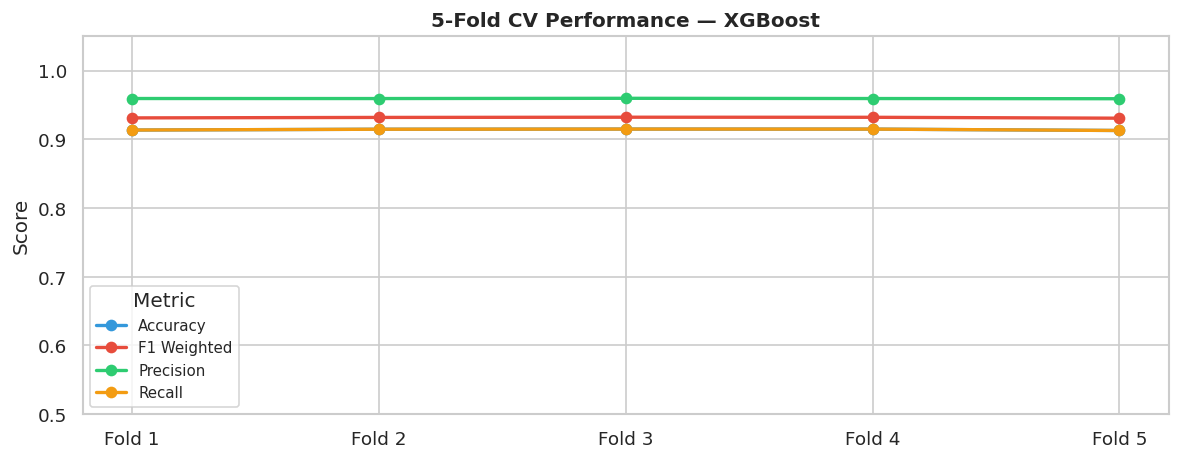

In [ ]:

# 5-FOLD CV FOR BEST MODEL ONLY


print(f"\n  Running 5-Fold CV for best model only: {best_model_name_tuned}")

SKF5 = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)


model_params = best_model_obj.get_params()


if 'early_stopping_rounds' in model_params:
    del model_params['early_stopping_rounds']
if 'eval_metric' in model_params:
    del model_params['eval_metric']

if 'callbacks' in model_params:
    del model_params['callbacks']

cv_pipeline_best = ImbPipeline([
    ('smote', SMOTE(k_neighbors=5, random_state=42)),
    ('model', best_model_obj.__class__(**model_params))
])
cv_results_best = cross_validate(
    cv_pipeline_best, X_train_ext, y_train_ext,
    cv=SKF5,
    scoring=['accuracy', 'f1_weighted', 'precision_weighted', 'recall_weighted'],
    return_train_score=False,
    n_jobs=-1, verbose=0
)

print(f"\n  5-Fold CV Results — {best_model_name_tuned}:")
print("  " + "=" * 55)
for metric in ['accuracy', 'f1_weighted', 'precision_weighted', 'recall_weighted']:
    scores = cv_results_best[f'test_{metric}']
    print(f"  {metric:28s}: {scores.mean():.4f} +/- {scores.std():.4f}")
    print(f"    folds: {[f'{s:.4f}' for s in scores]}")


benchmark_results[best_model_name_tuned]['CV Mean F1'] = round(
    cv_results_best['test_f1_weighted'].mean(), 4)
benchmark_results[best_model_name_tuned]['CV Std F1'] = round(
    cv_results_best['test_f1_weighted'].std(), 4)

fig, ax = plt.subplots(figsize=(10, 4))
cv_metric_map = {
    'Accuracy':    cv_results_best['test_accuracy'],
    'F1 Weighted': cv_results_best['test_f1_weighted'],
    'Precision':   cv_results_best['test_precision_weighted'],
    'Recall':      cv_results_best['test_recall_weighted'],
}
cv_colors = ['#3498db', '#e74c3c', '#2ecc71', '#f39c12']

for (mname, scores), color in zip(cv_metric_map.items(), cv_colors):
    ax.plot(range(1, 6), scores, marker='o', label=mname, color=color, lw=2)

ax.set_xticks(range(1, 6))
ax.set_xticklabels([f'Fold {i}' for i in range(1, 6)])
ax.set_title(f'5-Fold CV Performance — {best_model_name_tuned}',
             fontsize=12, fontweight='bold')
ax.set_ylabel('Score')
ax.set_ylim(0.5, 1.05)
ax.legend(title='Metric', fontsize=9)
plt.tight_layout()
plt.savefig('cross_validation.png', bbox_inches='tight', dpi=150)
plt.show()

In [ ]:


# PROFESSIONAL BENCHMARKING REPORT

print("   PROFESSIONAL PERFORMANCE BENCHMARKING REPORT")


rank_cols = ['Accuracy', 'Precision (W)', 'Recall (W)',
             'F1 (Weighted)', 'ROC-AUC (Macro)', 'CV Mean F1',
             'CV Std F1', 'Train Time (s)', 'Pred Time (ms)']

bench_df_final = pd.DataFrame(benchmark_results).T.sort_values('F1 (Weighted)', ascending=False)
bench_df_final.index.name = 'Model'

print("\n  RANKED TABLE (1 = best F1):")
print(bench_df_final[rank_cols].to_string())

print(f"""

    SELECTED FOR DEPLOYMENT
   Model      : {best_model_name_tuned:<43}|
   F1 (Wt.)   : {best_f1_tuned:.4f}
   Accuracy   : {benchmark_results[best_model_name_tuned]['Accuracy']:.4f}
   ROC-AUC    : {benchmark_results[best_model_name_tuned]['ROC-AUC (Macro)']:.4f}
   Train Time : {benchmark_results[best_model_name_tuned]['Train Time (s)']:.1f}s

  SPEED OPTIMISATION APPLIED

   1.  Levenshtein     : parallelised with joblib (4-8x faster)
   2. SMOTE           : capped at 80% of majority class (smaller data)
   3a. Logistic Reg    : saga solver, 300 iter, no search
   3b. Random Forest   : 150 trees, fixed params, no search
   3c. XGBoost         : hist method, early stop 20 rounds (~100 trees)
   3d. LightGBM        : early stop 20 rounds (~80 trees)
   4.  Benchmark loop  : no cross_validate inside loop
   5. CV              : runs once only for the best model

""")

# Bind to original variable names
best_model      = best_model_obj
best_model_name = best_model_name_tuned
X_test          = X_test_ext
y_test          = y_test_ext

   PROFESSIONAL PERFORMANCE BENCHMARKING REPORT

  RANKED TABLE (1 = best F1):
                     Accuracy  Precision (W)  Recall (W)  F1 (Weighted)  ROC-AUC (Macro)  CV Mean F1  CV Std F1  Train Time (s)  Pred Time (ms)
Model                                                                                                                                          
XGBoost                0.9286         0.9615      0.9286         0.9417           0.9809      0.9315     0.0005           933.3        29386.13
LightGBM               0.9154         0.9613      0.9154         0.9330           0.9813      0.0000     0.0000           740.1        88456.52
Random Forest          0.8889         0.9537      0.8889         0.9146           0.9704      0.0000     0.0000          2030.0         9435.90
Logistic Regression    0.1489         0.7064      0.1489         0.2289           0.6466      0.0000     0.0000          1530.0          215.68


    SELECTED FOR DEPLOYMENT                            

In [ ]:

# PREDICTION FUNCTION


known_drug_ids = set(le_combined.classes_)

def normalize_drug_input(drug_input):
    return str(drug_input).strip().upper()

def predict_interaction(drug1, drug2, verbose=True):
    d1 = normalize_drug_input(drug1)
    d2 = normalize_drug_input(drug2)

    unknown = [x for x in [d1, d2] if x not in known_drug_ids]
    if unknown:
        print(f"  Unknown drug ID(s): {unknown}")
        for u in unknown:
            best_match = min(known_drug_ids, key=lambda x: Levenshtein.distance(u, x))
            print(f"   Closest known ID to '{u}': {best_match}")
        return None

    d1_enc  = le_combined.transform([d1])[0]
    d2_enc  = le_combined.transform([d2])[0]
    lev_sim = levenshtein_similarity(d1, d2)

    drug1_num_val = float(str(d1).replace('DB', '')) if 'DB' in str(d1) else 0.0
    drug2_num_val = float(str(d2).replace('DB', '')) if 'DB' in str(d2) else 0.0
    drug_id_diff  = abs(drug1_num_val - drug2_num_val)
    drug_id_sum   = drug1_num_val + drug2_num_val
    drug_id_ratio = min(drug1_num_val, drug2_num_val) / max(drug1_num_val, drug2_num_val, 1)

    X_input = pd.DataFrame({
        'drug1_encoded':   [d1_enc],
        'drug2_encoded':   [d2_enc],
        'lev_similarity':  [lev_sim],
        'drug_id_diff':    [drug_id_diff],
        'drug_id_sum':     [drug_id_sum],
        'drug_id_ratio':   [drug_id_ratio],
        'desc_word_count': [0],
        'desc_has_cyp':    [0],
        'desc_has_excret': [0],
        'desc_has_serum':  [0],
    })

    pred_encoded = best_model.predict(X_input)[0]
    pred_proba   = best_model.predict_proba(X_input)[0]
    pred_class   = le_target.inverse_transform([pred_encoded])[0]
    confidence   = pred_proba.max()

    class_probs = {cls: float(f'{prob:.4f}')
                   for cls, prob in zip(le_target.classes_, pred_proba)}

    if verbose:

        print("  Drug-Drug Interaction Prediction Report")

        print(f"  Drug 1               : {d1}")
        print(f"  Drug 2               : {d2}")
        print(f"  Levenshtein Sim.     : {lev_sim:.4f}")

        print(f"  Predicted Severity   : {pred_class}")
        print(f"  Confidence Score     : {confidence * 100:.2f}%")

        print("  Class Probabilities:")
        for cls, prob in sorted(class_probs.items(), key=lambda x: -x[1]):
            bar = '' * int(prob * 30)
            print(f"    {cls:25s}: {prob * 100:5.2f}%  {bar}")


    return {
        'drug1_id':       d1,
        'drug2_id':       d2,
        'lev_similarity': lev_sim,
        'severity':       pred_class,
        'confidence':     confidence,
        'probabilities':  class_probs
    }

print("predict_interaction() is ready!")

predict_interaction() is ready!


In [ ]:
predict_interaction("DB00001", "DB01254")
predict_interaction("DB00001", "DB06695")

  Drug-Drug Interaction Prediction Report
  Drug 1               : DB00001
  Drug 2               : DB01254
  Levenshtein Sim.     : 0.4286
  Predicted Severity   : Moderate-Other
  Confidence Score     : 96.94%
  Class Probabilities:
    Moderate-Other           : 96.94%  
    High                     :  3.05%  
    Moderate-Metabolism      :  0.01%  
    Low                      :  0.00%  
  Drug-Drug Interaction Prediction Report
  Drug 1               : DB00001
  Drug 2               : DB06695
  Levenshtein Sim.     : 0.4286
  Predicted Severity   : Moderate-Other
  Confidence Score     : 98.62%
  Class Probabilities:
    Moderate-Other           : 98.62%  
    High                     :  1.37%  
    Moderate-Metabolism      :  0.01%  
    Low                      :  0.00%  


{'drug1_id': 'DB00001',
 'drug2_id': 'DB06695',
 'lev_similarity': 0.4285714285714286,
 'severity': 'Moderate-Other',
 'confidence': np.float32(0.98619395),
 'probabilities': {'High': 0.0137,
  'Low': 0.0,
  'Moderate-Metabolism': 0.0001,
  'Moderate-Other': 0.9862}}

In [ ]:
drug_pairs = [
    ("DB00001", "DB01254"),
    ("DB00001", "DB06695"),
    ("DB00001", "DB01609"),
    ("DB00001", "DB01586"),
    ("DB00001", "DB03619"),
]

print(f"{'Drug 1':<12} {'Drug 2':<12} {'Severity':<25} {'Confidence':>12}")

for d1, d2 in drug_pairs:
    r = predict_interaction(d1, d2, verbose=False)
    if r:
        print(f"{r['drug1_id']:<12} {r['drug2_id']:<12} "
              f"{r['severity']:<25} {r['confidence']*100:>10.2f}%")

Drug 1       Drug 2       Severity                    Confidence
DB00001      DB01254      Moderate-Other                 96.94%
DB00001      DB06695      Moderate-Other                 98.62%
DB00001      DB01609      Moderate-Other                 90.06%
DB00001      DB01586      Moderate-Other                 92.57%
DB00001      DB03619      Moderate-Other                 97.73%


In [ ]:

# SAVE MODEL ARTIFACTS

metadata = {
    'best_model_name':    best_model_name,
    'features':           FEATURES_EXT,
    'target':             TARGET,
    'classes':            le_target.classes_.tolist(),
    'known_drug_ids':     list(known_drug_ids),
    'dataset_shape':      df.shape,
    'train_size':         X_train_ext.shape[0],
    'test_size':          X_test_ext.shape[0],
    'test_weighted_f1':   results[best_model_name]['F1 (Weighted)'],
    'metabolism_keywords':METABOLISM_KEYWORDS,
    'trained_at':         str(datetime.datetime.now()),
}

joblib.dump(best_model,  'best_model.pkl',  compress=3)
joblib.dump(le_combined, 'le_combined.pkl', compress=3)
joblib.dump(le_target,   'le_target.pkl',   compress=3)
joblib.dump(metadata,    'metadata.pkl',    compress=3)

print("Saved: best_model.pkl, le_combined.pkl, le_target.pkl, metadata.pkl")

loaded_model  = joblib.load('best_model.pkl')
loaded_le     = joblib.load('le_combined.pkl')
loaded_target = joblib.load('le_target.pkl')
loaded_meta   = joblib.load('metadata.pkl')

test_pred = loaded_model.predict(X_test[:5])
print(f"Verification predictions: {loaded_target.inverse_transform(test_pred).tolist()}")
print(f"Model: {loaded_meta['best_model_name']}")
print("All artifacts verified!")

Saved: best_model.pkl, le_combined.pkl, le_target.pkl, metadata.pkl
Verification predictions: ['Moderate-Metabolism', 'Moderate-Other', 'High', 'Moderate-Other', 'High']
Model: XGBoost
All artifacts verified!


In [ ]:


# STANDALONE LOADER


_model   = joblib.load('best_model.pkl')
_le      = joblib.load('le_combined.pkl')
_le_tgt  = joblib.load('le_target.pkl')
_meta    = joblib.load('metadata.pkl')
_known   = set(_meta['known_drug_ids'])

def _lev_sim(s1, s2):
    d = Levenshtein.distance(str(s1), str(s2))
    return 1.0 - d / max(len(str(s1)), len(str(s2)), 1)

def predict_from_saved(drug1, drug2):
    d1 = str(drug1).strip().upper()
    d2 = str(drug2).strip().upper()

    unknown = [x for x in [d1, d2] if x not in _known]
    if unknown:
        print(f"Unknown drug ID(s): {unknown}")
        return None

    d1e = _le.transform([d1])[0]
    d2e = _le.transform([d2])[0]
    ls  = _lev_sim(d1, d2)

    drug1_num_val = float(str(d1).replace('DB', '')) if 'DB' in str(d1) else 0.0
    drug2_num_val = float(str(d2).replace('DB', '')) if 'DB' in str(d2) else 0.0
    drug_id_diff  = abs(drug1_num_val - drug2_num_val)
    drug_id_sum   = drug1_num_val + drug2_num_val
    drug_id_ratio = min(drug1_num_val, drug2_num_val) / max(drug1_num_val, drug2_num_val, 1)

    X = pd.DataFrame({
        'drug1_encoded':   [d1e],
        'drug2_encoded':   [d2e],
        'lev_similarity':  [ls],
        'drug_id_diff':    [drug_id_diff],
        'drug_id_sum':     [drug_id_sum],
        'drug_id_ratio':   [drug_id_ratio],
        'desc_word_count': [0],
        'desc_has_cyp':    [0],
        'desc_has_excret': [0],
        'desc_has_serum':  [0],
    })

    pred  = _model.predict(X)[0]
    proba = _model.predict_proba(X)[0]
    cls   = _le_tgt.inverse_transform([pred])[0]

    print(f"\n[{cls.upper()}] {d1} + {d2}")
    print(f"   Predicted Severity : {cls}")
    print(f"   Confidence Score   : {proba.max()*100:.2f}%")
    print("   Class Probabilities:")
    for c, p in sorted(zip(_le_tgt.classes_, proba), key=lambda x: -x[1]):
        print(f"     {c:25s}: {p*100:.2f}%")

    return {
        'severity':      cls,
        'confidence':    float(proba.max()),
        'probabilities': dict(zip(_le_tgt.classes_, proba.tolist()))
    }

predict_from_saved("DB00001", "DB01254")


[MODERATE-OTHER] DB00001 + DB01254
   Predicted Severity : Moderate-Other
   Confidence Score   : 96.94%
   Class Probabilities:
     Moderate-Other           : 96.94%
     High                     : 3.05%
     Moderate-Metabolism      : 0.01%
     Low                      : 0.00%


{'severity': 'Moderate-Other',
 'confidence': 0.9694268703460693,
 'probabilities': {'High': 0.030483141541481018,
  'Low': 1.848657689151878e-07,
  'Moderate-Metabolism': 8.980913844425231e-05,
  'Moderate-Other': 0.9694268703460693}}

In [ ]:

# FINAL SUMMARY



print("  DDI SEVERITY PREDICTION SYSTEM — FINAL SUMMARY")

print(f"\n  Dataset : {df.shape[0]:,} interactions | "
      f"{pd.concat([df['drug1_id'], df['drug2_id']]).nunique():,} unique drugs")
print("\n  Classes :")
for c in class_order:
    n = (df['severity_new'] == c).sum()
    print(f"     {c:25s}: {n:,}")
print(f"\n  Best Model       : {best_model_name}")
print(f"     Weighted F1    : {results[best_model_name]['F1 (Weighted)']:.4f}")
print(f"     Accuracy       : {results[best_model_name]['Accuracy']:.4f}")
print(f"     Precision (W)  : {results[best_model_name]['Precision']:.4f}")
print(f"     Recall (W)     : {results[best_model_name]['Recall']:.4f}")
print(f"     Train Time     : {results[best_model_name]['Train Time (s)']:.1f}s")
print("\n  Saved Artifacts  :")
print("     best_model.pkl | le_combined.pkl | le_target.pkl | metadata.pkl")
print("\n  Usage:")
print("     predict_interaction('DB00001', 'DB01254')")
print("     predict_from_saved('DB00001', 'DB01254')")


  DDI SEVERITY PREDICTION SYSTEM — FINAL SUMMARY

  Dataset : 2,910,552 interactions | 4,629 unique drugs

  Classes :
     Low                      : 3,188
     Moderate-Metabolism      : 1,063,168
     Moderate-Other           : 1,752,878
     High                     : 91,318

  Best Model       : XGBoost
     Weighted F1    : 0.9417
     Accuracy       : 0.9286
     Precision (W)  : 0.9615
     Recall (W)     : 0.9286
     Train Time     : 933.3s

  Saved Artifacts  :
     best_model.pkl | le_combined.pkl | le_target.pkl | metadata.pkl

  Usage:
     predict_interaction('DB00001', 'DB01254')
     predict_from_saved('DB00001', 'DB01254')
